In [6]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="o9gkDNhTvv9r3Uy2bdT2")
project = rf.workspace("visea").project("car-segmentation-vacre")
version = project.version(1)
dataset = version.download("yolov8")



loading Roboflow workspace...
loading Roboflow project...


In [7]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.158 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 48.0/112.6 GB disk)


In [8]:
!yolo task = segment mode = train  data = /content/car-segmentation-1/data.yaml model=yolov8s-seg.pt epochs=100 imgsz=640

Ultralytics 8.4.158 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/car-segmentation-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=None, opset=N

In [11]:
!yolo task = segment mode = predict data=/content/runs/segment/train-2/weights/best.pt imgsz=640 conf=0.5 source=car-segmentation-1/test/images

Ultralytics 8.4.158 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-seg summary (fused): 136 layers, 2,722,980 parameters, 0 gradients, 9.3 GFLOPs

image 1/57 /content/car-segmentation-1/test/images/156551_preview_png.rf.f635b7bc37acd06bf85deaeb929ba8dd.jpg: 480x640 1 car, 11.7ms
image 2/57 /content/car-segmentation-1/test/images/2008-Morgan-Life-Car-Side-Speed-1024x768_png.rf.0f2ca68c88b3d602795962c34561d05d.jpg: 480x640 1 car, 11.8ms
image 3/57 /content/car-segmentation-1/test/images/2009-Ford-Kuga-Show-Car-Side-1280x960_png.rf.42178a592a0deec5f55b9084aa938d76.jpg: 480x640 1 car, 11.1ms
image 4/57 /content/car-segmentation-1/test/images/2019-acura-rdx-11_png.rf.5a886f009af63b1a0099bf28242a9fab.jpg: 480x640 1 car, 12.0ms
image 5/57 /content/car-segmentation-1/test/images/2019-ferrari-488-spider-side-view-carbuzz-669506_png.rf.88c7d2a71941cd15994a6d528155fc1f.jpg: 480x640 1 car, 10.7ms
image 6/57 /content/car-segmentation-1/test/images/202-2028012_car-png-hd-sid

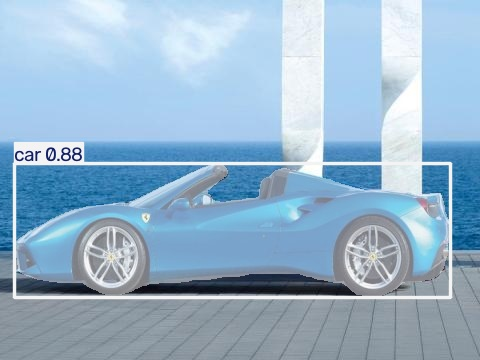

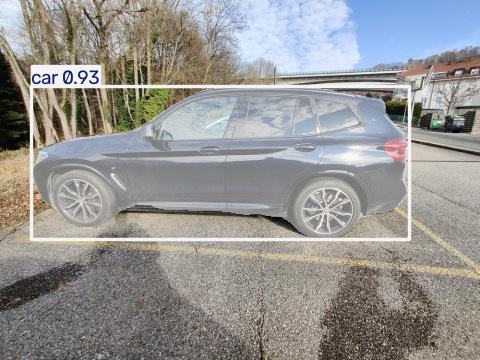

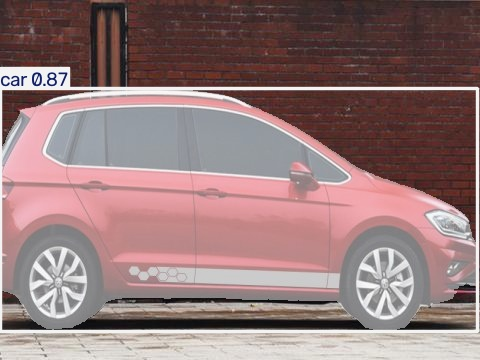

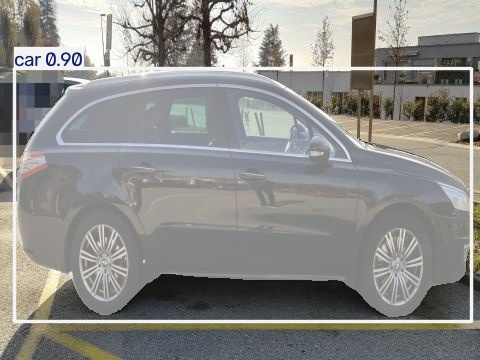

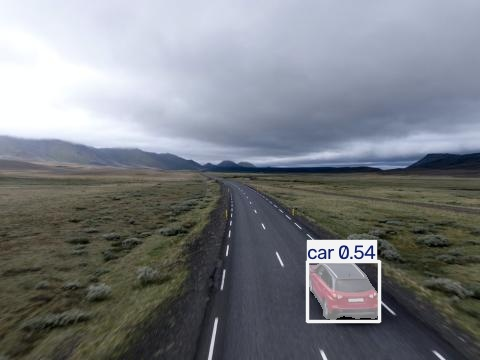

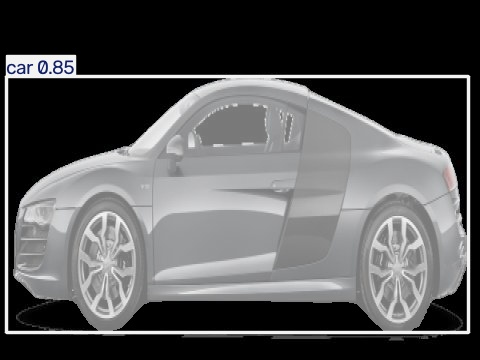

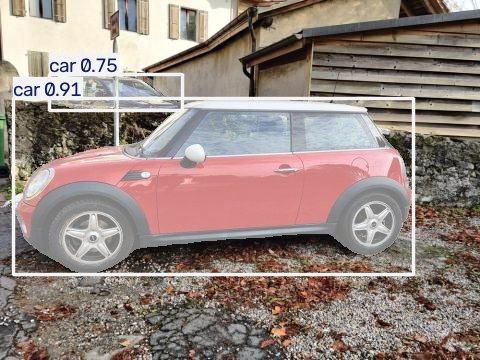

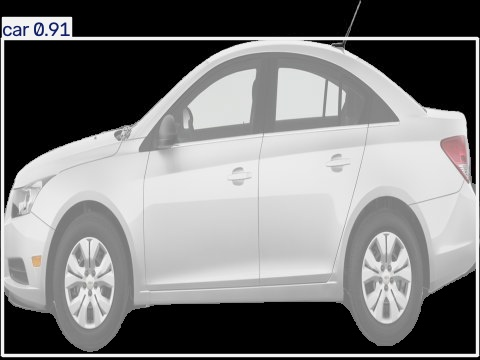

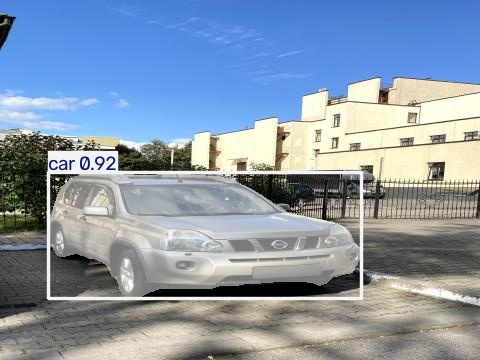

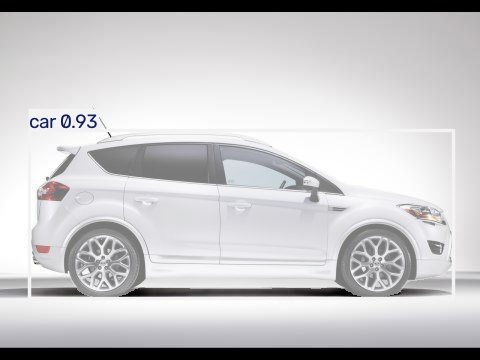

In [12]:
# Display inference on ALL test images
import glob
from IPython.display import Image, display

for imageName in glob.glob("runs/segment/predict/*.jpg")[:10]: #assuming JPG

    print("\n")
    display(Image(filename=imageName))



In [13]:
from google.colab import files
files.download('/content/runs/segment/train-2/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>